# Assignment 4 — Automated Coffee Ordering System using Multi-Agent LangGraph

**Beginner-level, end-to-end implementation**

This notebook follows the assignment architecture without adding extra agent layers:

`START → planner → (menu_agent | order_agent | placement_agent) → evaluator → END`

If the evaluator rejects a response, the graph returns to `planner`, with a maximum of **2 retries**.

The assignment specifically requires a planner, specialised agents, tools, shared state, an evaluator/retry loop, and the six test scenarios. The graph and terminology below follow that specification.


## 1. Required technology

- Python **3.11.9**
- `langchain==1.4.3`
- `langchain-core==1.6.5`
- `langgraph==1.2.12`
- `langchain-openai==1.6.3`
- `openai==2.45.0`
- `langchain-google-genai==4.4.0`
- `google-genai==2.20.0`
- `faiss-cpu`
- Jupyter Notebook
- Gemini free API key

**Important:** the notebook uses Gemini for the planner and evaluator. The coffee-shop data, prices, availability, cart and order placement remain deterministic Python data/tools.


In [1]:
%pip install -q \
    langchain==1.4.3 \
    langchain-core==1.6.5 \
    langgraph==1.2.12 \
    langchain-openai==1.6.3 \
    openai==2.45.0 \
    langchain-google-genai==4.4.0 \
    google-genai==2.20.0 \
    faiss-cpu \
    "pydantic>=2,<3" \
    python-dotenv \
    graphviz


Note: you may need to restart the kernel to use updated packages.


## 2. Imports and Gemini setup

Enter the Gemini API key when prompted. Do not put the real key directly into a shared notebook.


In [ ]:
import os
import json
import uuid
import getpass
from typing import Literal, TypedDict

from pydantic import BaseModel, Field
from dotenv import load_dotenv

from langchain_core.messages import HumanMessage, AIMessage
from langchain_core.tools import tool
from langchain_google_genai import ChatGoogleGenerativeAI

from langgraph.graph import StateGraph, START, END

from IPython.display import display, Image, Markdown

load_dotenv()

if not os.environ.get("GEMINI_API_KEY"):
    os.environ["GEMINI_API_KEY"] = getpass.getpass("...............")
GEMINI_MODEL = os.environ.get("GEMINI_MODEL", "gemini-3.1-flash-lite")

llm = ChatGoogleGenerativeAI(
    model=GEMINI_MODEL,
    temperature=0,
)

print("Gemini model:", GEMINI_MODEL)


Gemini model: gemini-3.1-flash-lite


## 3. Coffee shop resource pool

The assignment allows the tools to use a Python dictionary/JSON file as the menu database.

The resource pool is intentionally small and beginner-friendly. All menu facts come from this class — agents do not invent prices or availability.


In [3]:
class CoffeeShopResourcePool:
    # Six coffee types required for this project.
    MENU = {
        "latte": {
            "name": "Latte",
            "prices": {"small": 4.00, "medium": 5.00, "large": 6.00},
            "milks": ["whole", "skim", "oat", "almond"],
            "extras": {"vanilla": 0.75, "caramel": 0.75, "extra_shot": 1.00},
            "available": True,
        },
        "cappuccino": {
            "name": "Cappuccino",
            "prices": {"small": 4.00, "medium": 5.00, "large": 6.00},
            "milks": ["whole", "skim", "oat", "almond"],
            "extras": {"vanilla": 0.75, "caramel": 0.75, "extra_shot": 1.00},
            "available": True,
        },
        "americano": {
            "name": "Americano",
            "prices": {"small": 3.00, "medium": 4.00, "large": 5.00},
            "milks": ["whole", "skim", "oat", "almond"],
            "extras": {"extra_shot": 1.00},
            "available": True,
        },
        "espresso": {
            "name": "Espresso",
            "prices": {"small": 2.50, "medium": 3.00, "large": 3.50},
            "milks": ["whole", "skim", "oat", "almond"],
            "extras": {"extra_shot": 1.00},
            "available": True,
        },
        "mocha": {
            "name": "Mocha",
            "prices": {"small": 4.50, "medium": 5.50, "large": 6.50},
            "milks": ["whole", "skim", "oat", "almond"],
            "extras": {"vanilla": 0.75, "caramel": 0.75, "whipped_cream": 0.50},
            "available": True,
        },
        "caramel_macchiato": {
            "name": "Caramel Macchiato",
            "prices": {"small": 5.00, "medium": 6.00, "large": 7.00},
            "milks": ["whole", "skim", "oat", "almond"],
            "extras": {"extra_shot": 1.00, "whipped_cream": 0.50},
            # Deliberately unavailable for Scenario 5.
            "available": False,
        },
    }

    TAX_RATE = 0.05

    @staticmethod
    def get_menu(category=None):
        if category is None:
            return CoffeeShopResourcePool.MENU
        return {
            name: item
            for name, item in CoffeeShopResourcePool.MENU.items()
            if category.lower() == "coffee"
        }

    @staticmethod
    def check_availability(item_name):
        key = item_name.lower().strip().replace(" ", "_")
        item = CoffeeShopResourcePool.MENU.get(key)
        return bool(item and item["available"])

    @staticmethod
    def validate_order(item, size, milk, extras):
        key = item.lower().strip().replace(" ", "_")
        if key not in CoffeeShopResourcePool.MENU:
            return {"valid": False, "reason": "Item is not on the menu."}

        data = CoffeeShopResourcePool.MENU[key]

        if not data["available"]:
            return {"valid": False, "reason": f"{data['name']} is currently out of stock."}

        if size not in data["prices"]:
            return {"valid": False, "reason": f"Invalid size. Choose: {list(data['prices'])}."}

        if milk not in data["milks"]:
            return {"valid": False, "reason": f"Invalid milk. Choose: {data['milks']}."}

        for extra in extras:
            if extra not in data["extras"]:
                return {"valid": False, "reason": f"{extra} is not available for {data['name']}."}

        return {"valid": True, "reason": "Order item is valid."}

    @staticmethod
    def update_cart(cart, action, item):
        cart = list(cart)

        if action == "add":
            cart.append(item)
        elif action == "remove":
            cart = [
                x for x in cart
                if not (
                    x["item"] == item["item"]
                    and x["size"] == item["size"]
                    and x["milk"] == item["milk"]
                )
            ]
        elif action == "clear":
            cart = []

        return cart

    @staticmethod
    def calculate_total(cart):
        subtotal = round(sum(x["price"] * x["quantity"] for x in cart), 2)
        tax = round(subtotal * CoffeeShopResourcePool.TAX_RATE, 2)
        total = round(subtotal + tax, 2)
        return {"subtotal": subtotal, "tax": tax, "total": total}

    @staticmethod
    def place_order(cart, customer_name="Customer"):
        if not cart:
            raise ValueError("Cannot place an empty order.")

        order_id = str(uuid.uuid4())[:8].upper()
        return {
            "order_id": order_id,
            "pickup_time": "about 8 minutes",
            "customer_name": customer_name,
        }


## 4. Tools

These are the six tools specified in the assignment.

- `get_menu`
- `check_availability`
- `validate_order`
- `update_cart`
- `calculate_total`
- `place_order`


In [4]:
@tool
def get_menu(category: str = "coffee"):
    """Return the coffee menu from the resource pool."""
    return CoffeeShopResourcePool.get_menu(category)


@tool
def check_availability(item_name: str):
    """Check whether a coffee is currently available."""
    return CoffeeShopResourcePool.check_availability(item_name)


@tool
def validate_order(item: str, size: str, milk: str, extras: list[str]):
    """Validate a coffee item and its customizations."""
    return CoffeeShopResourcePool.validate_order(item, size, milk, extras)


@tool
def update_cart(cart: list, action: str, item: dict):
    """Add/remove/clear an item in the cart."""
    return CoffeeShopResourcePool.update_cart(cart, action, item)


@tool
def calculate_total(cart: list):
    """Calculate subtotal, tax and total."""
    return CoffeeShopResourcePool.calculate_total(cart)


@tool
def place_order(cart: list, customer_name: str = "Customer"):
    """Submit the order to the mock backend."""
    return CoffeeShopResourcePool.place_order(cart, customer_name)


## 5. Shared graph state

The assignment specifies these shared fields: `messages`, `intent`, `cart`, `order_id`, `evaluation`, and `retry_count`.

A small `confirmed` field is also kept so the placement agent can safely require confirmation before calling `place_order`.


In [5]:
class CoffeeState(TypedDict, total=False):
    messages: list
    intent: Literal["browse_menu", "build_order", "place_order"]
    cart: list
    order_id: str | None
    evaluation: dict
    retry_count: int
    response: str
    confirmed: bool
    customer_name: str


## 6. Structured outputs for planner and evaluator

The planner only has three allowed intents, exactly as required by the assignment.

The evaluator returns a verdict, score and feedback.


In [6]:
class PlannerResult(BaseModel):
    intent: Literal["browse_menu", "build_order", "place_order"]


class EvaluationResult(BaseModel):
    verdict: Literal["approved", "rejected"]
    score: int = Field(ge=1, le=5)
    feedback: str


planner_llm = llm.with_structured_output(PlannerResult)
evaluator_llm = llm.with_structured_output(EvaluationResult)


## 7. Helper functions

These helpers keep the agent nodes short and readable. They do not add extra graph nodes.


In [7]:
def latest_user_message(state):
    for message in reversed(state.get("messages", [])):
        if isinstance(message, HumanMessage):
            return message.content
    return ""


def money(value):
    return f"${value:.2f}"


def find_coffee_in_text(text):
    text = text.lower()
    for key, item in CoffeeShopResourcePool.MENU.items():
        if key in text or item["name"].lower() in text:
            return key
    return None


def find_size(text):
    text = text.lower()
    for size in ["small", "medium", "large"]:
        if size in text:
            return size
    return None


def find_milk(text):
    text = text.lower()
    for milk in ["almond", "oat", "skim", "whole"]:
        if milk in text:
            return milk
    return None


def find_extras(text, item_key):
    text = text.lower()
    available = CoffeeShopResourcePool.MENU[item_key]["extras"]
    return [extra for extra in available if extra.replace("_", " ") in text]


def is_confirmation(text):
    text = text.lower().strip()
    return any(
        phrase in text
        for phrase in ["yes", "confirm", "confirmed", "place it", "go ahead", "that's correct"]
    )


def format_cart(cart):
    if not cart:
        return "Cart is empty."

    lines = []
    for x in cart:
        extras = f", extras: {', '.join(x['extras'])}" if x["extras"] else ""
        lines.append(
            f"{x['quantity']} × {x['size'].title()} {x['name']} "
            f"({x['milk']} milk{extras}) — {money(x['price'])}"
        )
    return "\n".join(lines)


## 8. Planner Agent

The planner reads the latest user message and current state, then writes one of:

- `browse_menu`
- `build_order`
- `place_order`

The routing function below reads this value and chooses the next graph node.


In [8]:
def planner_node(state: CoffeeState):
    user_text = latest_user_message(state)

    prompt = f"""
You are the planner for a coffee ordering system.

Choose exactly one intent:
- browse_menu: the user wants to see/menu information.
- build_order: the user wants to add, change or remove coffee items.
- place_order: the user wants to place/confirm an existing order.

Current cart:
{state.get("cart", [])}

Latest user message:
{user_text}
"""

    result = planner_llm.invoke([HumanMessage(content=prompt)])

    return {
        "intent": result.intent,
        "retry_count": state.get("retry_count", 0),
    }


def route_from_planner(state: CoffeeState):
    return state["intent"]


## 9. Menu Agent

The menu agent uses `get_menu` and `check_availability`. It does not use hard-coded menu information in its response.


In [9]:
def menu_agent_node(state: CoffeeState):
    menu = get_menu.invoke({"category": "coffee"})

    lines = ["Here is our current coffee menu:"]
    for key, item in menu.items():
        availability = check_availability.invoke({"item_name": key})
        status = "Available" if availability else "Out of stock"

        price_text = ", ".join(
            f"{size.title()} {money(price)}"
            for size, price in item["prices"].items()
        )

        lines.append(
            f"- {item['name']}: {price_text} — {status}"
        )

    lines.append("Milk options: whole, skim, oat, almond.")
    lines.append("Add-ons depend on the coffee and are validated when you build an order.")

    return {"response": "\n".join(lines)}


## 10. Order Agent

The order agent extracts the coffee, size, milk and extras from the user's message, then validates the item using the tool.

**Important:** if size or milk is missing, it asks instead of guessing. This directly covers Scenario 3.


In [10]:
def order_agent_node(state: CoffeeState):
    user_text = latest_user_message(state)
    item_key = find_coffee_in_text(user_text)

    if not item_key:
        return {
            "response": "I could not find a coffee item in your message. Please choose a coffee from the menu.",
        }

    size = find_size(user_text)
    milk = find_milk(user_text)
    extras = find_extras(user_text, item_key)

    missing = []
    if not size:
        missing.append("size")
    if not milk:
        missing.append("milk type")

    if missing:
        return {
            "response": (
                f"I can add {CoffeeShopResourcePool.MENU[item_key]['name']}, "
                f"but I need the following details: {', '.join(missing)}. "
                "Please tell me the size and milk type."
            )
        }

    validation = validate_order.invoke({
        "item": item_key,
        "size": size,
        "milk": milk,
        "extras": extras,
    })

    if not validation["valid"]:
        if not CoffeeShopResourcePool.check_availability(item_key):
            alternatives = [
                item["name"]
                for key, item in CoffeeShopResourcePool.MENU.items()
                if item["available"] and key != item_key
            ][:3]

            return {
                "response": (
                    f"{CoffeeShopResourcePool.MENU[item_key]['name']} is currently out of stock. "
                    f"Available alternatives include: {', '.join(alternatives)}."
                )
            }

        return {"response": validation["reason"]}

    item_data = CoffeeShopResourcePool.MENU[item_key]
    price = item_data["prices"][size] + sum(
        item_data["extras"][extra] for extra in extras
    )

    cart_item = {
        "item": item_key,
        "name": item_data["name"],
        "size": size,
        "milk": milk,
        "extras": extras,
        "quantity": 1,
        "price": round(price, 2),
    }

    new_cart = update_cart.invoke({
        "cart": state.get("cart", []),
        "action": "add",
        "item": cart_item,
    })

    return {
        "cart": new_cart,
        "response": (
            f"Added 1 × {size.title()} {item_data['name']} ({milk} milk) "
            f"for {money(price)}. Would you like anything else?"
        ),
    }


## 11. Placement Agent

The placement agent follows the assignment rule:

1. Never place an empty cart.
2. First show the final cart and total and ask for confirmation.
3. Only after confirmation call `place_order`.


In [11]:
def placement_agent_node(state: CoffeeState):
    cart = state.get("cart", [])

    if not cart:
        return {
            "confirmed": False,
            "response": "Your cart is empty. Please tell me which coffee you would like before placing an order.",
        }

    user_text = latest_user_message(state)

    if not is_confirmation(user_text):
        totals = calculate_total.invoke({"cart": cart})
        return {
            "confirmed": False,
            "response": (
                "Here is your final order:\n\n"
                f"{format_cart(cart)}\n\n"
                f"Subtotal: {money(totals['subtotal'])}\n"
                f"Tax: {money(totals['tax'])}\n"
                f"Total: {money(totals['total'])}\n\n"
                "Would you like me to place this order? Please reply Yes to confirm."
            ),
        }

    result = place_order.invoke({
        "cart": cart,
        "customer_name": state.get("customer_name", "Customer"),
    })

    return {
        "order_id": result["order_id"],
        "confirmed": True,
        "response": (
            f"Order #{result['order_id']} placed successfully. "
            f"Ready in {result['pickup_time']}."
        ),
    }


## 12. Evaluator Agent

The evaluator is an **LLM-as-judge**.

Rubric from the assignment:

1. Correctness
2. Completeness
3. No hallucination
4. Intent match

The evaluator returns `approved/rejected`, a score from 1–5 and feedback.

The retry routing sends a rejected response back to the planner, up to 2 retries.


In [12]:
def evaluator_node(state: CoffeeState):
    response = state.get("response", "")
    intent = state.get("intent", "")
    cart = state.get("cart", [])

    reference_menu = CoffeeShopResourcePool.MENU

    prompt = f"""
You are the evaluator for a coffee ordering system.

Evaluate the latest agent response using this rubric:
1. Correctness: menu items, availability and prices must match the tool data.
2. Completeness: required details must not be missing.
3. No hallucination: do not allow invented menu items, prices or offers.
4. Intent match: answer the user's requested intent.

Current intent:
{intent}

Current cart:
{json.dumps(cart, indent=2)}

Authoritative menu/tool data:
{json.dumps(reference_menu, indent=2)}

Latest agent response:
{response}

Approve a response that correctly asks for missing required order details,
correctly reports an unavailable item, correctly summarizes an order for confirmation,
or correctly reports a successfully placed order.
"""

    result = evaluator_llm.invoke([HumanMessage(content=prompt)])

    retry_count = state.get("retry_count", 0)

    if result.verdict == "rejected":
        retry_count += 1

    return {
        "evaluation": {
            "verdict": result.verdict,
            "score": result.score,
            "feedback": result.feedback,
        },
        "retry_count": retry_count,
    }


def route_from_evaluator(state: CoffeeState):
    evaluation = state.get("evaluation", {})
    if evaluation.get("verdict") == "approved":
        return "end"

    if state.get("retry_count", 0) < 2:
        return "retry"

    return "end"


## 13. Build the LangGraph

This is the important graph section.

The graph contains exactly the assignment's main nodes:

`planner`, `menu_agent`, `order_agent`, `placement_agent`, `evaluator`

and the required conditional edges.


In [13]:
builder = StateGraph(CoffeeState)

builder.add_node("planner", planner_node)
builder.add_node("menu_agent", menu_agent_node)
builder.add_node("order_agent", order_agent_node)
builder.add_node("placement_agent", placement_agent_node)
builder.add_node("evaluator", evaluator_node)

builder.add_edge(START, "planner")

builder.add_conditional_edges(
    "planner",
    route_from_planner,
    {
        "browse_menu": "menu_agent",
        "build_order": "order_agent",
        "place_order": "placement_agent",
    },
)

builder.add_edge("menu_agent", "evaluator")
builder.add_edge("order_agent", "evaluator")
builder.add_edge("placement_agent", "evaluator")

builder.add_conditional_edges(
    "evaluator",
    route_from_evaluator,
    {
        "end": END,
        "retry": "planner",
    },
)

graph = builder.compile()

print("LangGraph compiled successfully.")


LangGraph compiled successfully.


## 14. Graph visualisation — same architecture as the assignment PDF

The assignment's architecture is:

`START → planner → (menu_agent | order_agent | placement_agent) → evaluator → END`

and:

`evaluator -- rejected + retry_count < 2 --> planner`

The next cell asks **LangGraph itself** to generate the graph representation. This is the visualisation to include in the submission.


In [14]:
# Mermaid source generated by LangGraph.
mermaid = graph.get_graph().draw_mermaid()

print(mermaid)


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	planner(planner)
	menu_agent(menu_agent)
	order_agent(order_agent)
	placement_agent(placement_agent)
	evaluator(evaluator)
	__end__([<p>__end__</p>]):::last
	__start__ --> planner;
	evaluator -. &nbsp;end&nbsp; .-> __end__;
	evaluator -. &nbsp;retry&nbsp; .-> planner;
	menu_agent --> evaluator;
	order_agent --> evaluator;
	placement_agent --> evaluator;
	planner -. &nbsp;browse_menu&nbsp; .-> menu_agent;
	planner -. &nbsp;build_order&nbsp; .-> order_agent;
	planner -. &nbsp;place_order&nbsp; .-> placement_agent;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



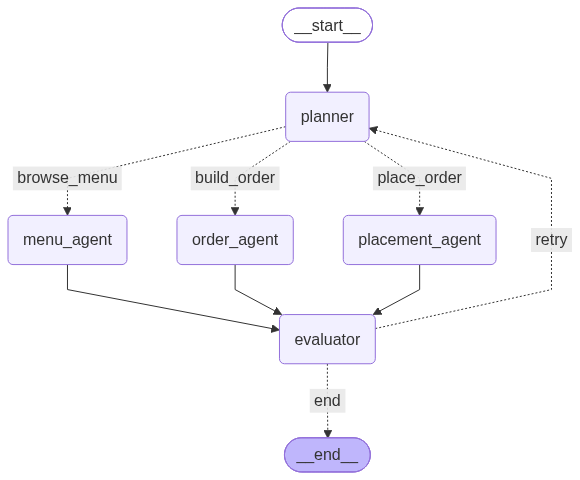

In [15]:
# Try to render the LangGraph diagram as a PNG inside Jupyter.
# If Mermaid rendering is unavailable in the environment, the Mermaid source above
# can still be pasted into a Mermaid renderer.

try:
    graph_png = graph.get_graph().draw_mermaid_png()
    display(Image(graph_png))
except Exception as e:
    print("PNG rendering is unavailable in this environment.")
    print("Use the Mermaid graph printed in the previous cell.")
    print("Reason:", e)


### Graph structure

```text
                 ┌──────────────┐
                 │    START     │
                 └──────┬───────┘
                        │
                        ▼
                 ┌──────────────┐
                 │   planner    │
                 └──────┬───────┘
                        │ conditional routing
          ┌─────────────┼─────────────┐
          ▼             ▼             ▼
   ┌────────────┐ ┌────────────┐ ┌─────────────────┐
   │ menu_agent │ │ order_agent│ │ placement_agent │
   └──────┬─────┘ └──────┬─────┘ └────────┬────────┘
          │              │                │
          └──────────────┼────────────────┘
                         ▼
                  ┌─────────────┐
                  │  evaluator  │
                  └──────┬──────┘
                     approved │
                         ┌────┴────┐
                         ▼         │ rejected
                      ┌─────┐      │ retry < 2
                      │ END │◄─────┘
                      └─────┘
                                │
                                ▼
                             planner
```


## 15. Simple runner

Use `run_chat()` for the six assignment scenarios or for your own messages.


In [16]:
def run_chat(user_text, state=None):
    if state is None:
        state = {
            "messages": [],
            "cart": [],
            "order_id": None,
            "evaluation": {},
            "retry_count": 0,
            "confirmed": False,
            "customer_name": "Customer",
        }

    state["messages"] = list(state.get("messages", []))
    state["messages"].append(HumanMessage(content=user_text))

    result = graph.invoke(state)

    # Keep the agent response as a message for the conversation.
    result["messages"] = list(result.get("messages", []))
    result["messages"].append(AIMessage(content=result.get("response", "")))

    print("USER:", user_text)
    print("\nASSISTANT:")
    print(result.get("response", ""))
    print("\nEVALUATION:")
    print(result.get("evaluation", {}))

    return result


# 16. Six required test scenarios

Run these one by one. The outputs are intentionally printed so they can be used as assignment logs/screenshots.


### Scenario 1 — Browse the menu

Expected route:

`planner → menu_agent → evaluator → END`


In [17]:
state_1 = run_chat("What coffees do you have?")


Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


USER: What coffees do you have?

ASSISTANT:
Here is our current coffee menu:
- Latte: Small $4.00, Medium $5.00, Large $6.00 — Available
- Cappuccino: Small $4.00, Medium $5.00, Large $6.00 — Available
- Americano: Small $3.00, Medium $4.00, Large $5.00 — Available
- Espresso: Small $2.50, Medium $3.00, Large $3.50 — Available
- Mocha: Small $4.50, Medium $5.50, Large $6.50 — Available
- Caramel Macchiato: Small $5.00, Medium $6.00, Large $7.00 — Out of stock
Milk options: whole, skim, oat, almond.
Add-ons depend on the coffee and are validated when you build an order.

EVALUATION:
{'verdict': 'approved', 'score': 5, 'feedback': 'The agent correctly listed all menu items, their prices, and their availability status according to the provided data. It also correctly identified the Caramel Macchiato as out of stock and provided the available milk options.'}


### Scenario 2 — Build an order

Expected route:

`planner → order_agent → evaluator → END`

Example from the assignment:

`I want a large latte with oat milk.`


In [18]:
state_2 = run_chat("I want a large latte with oat milk.")


USER: I want a large latte with oat milk.

ASSISTANT:
Added 1 × Large Latte (oat milk) for $6.00. Would you like anything else?

EVALUATION:
{'verdict': 'approved', 'score': 5, 'feedback': 'The agent correctly identified the item, size, milk preference, and price based on the provided menu data and successfully added it to the cart.'}


### Scenario 3 — Incomplete order

The order agent must ask for the missing size and milk type instead of guessing.


In [19]:
state_3 = run_chat("Get me a cappuccino.")


USER: Get me a cappuccino.

ASSISTANT:
I can add Cappuccino, but I need the following details: size, milk type. Please tell me the size and milk type.

EVALUATION:
{'verdict': 'approved', 'score': 5, 'feedback': 'The agent correctly identified the missing required information (size and milk type) for the requested item and prompted the user for these details.'}


### Scenario 4 — Place the order

Placement is deliberately two-step because the assignment says the system must show the final cart and ask for confirmation before placing.

First turn: request placement.

Second turn: confirm.


In [20]:
state_4 = run_chat(
    "I want a large latte with oat milk.",
    {
        "messages": [],
        "cart": [],
        "order_id": None,
        "evaluation": {},
        "retry_count": 0,
        "confirmed": False,
        "customer_name": "Customer",
    },
)

state_4 = run_chat("That's all, place my order.", state_4)
state_4 = run_chat("Yes, confirm and place it.", state_4)


USER: I want a large latte with oat milk.

ASSISTANT:
Added 1 × Large Latte (oat milk) for $6.00. Would you like anything else?

EVALUATION:
{'verdict': 'approved', 'score': 5, 'feedback': 'The agent correctly identified the item, size, milk preference, and price based on the provided menu data and successfully added it to the cart.'}
USER: That's all, place my order.

ASSISTANT:
Here is your final order:

1 × Large Latte (oat milk) — $6.00

Subtotal: $6.00
Tax: $0.30
Total: $6.30

Would you like me to place this order? Please reply Yes to confirm.

EVALUATION:
{'verdict': 'approved', 'score': 5, 'feedback': 'The agent correctly summarized the order, calculated the subtotal accurately based on the menu data, and appropriately asked for confirmation to proceed with the order.'}
USER: Yes, confirm and place it.

ASSISTANT:
Order #D64CFF5E placed successfully. Ready in about 8 minutes.

EVALUATION:
{'verdict': 'approved', 'score': 5, 'feedback': 'The agent correctly processed the order pl

### Scenario 5 — Unavailable item

`Caramel Macchiato` is deliberately marked out of stock in the resource pool so the system must not place it and should suggest alternatives.


In [21]:
state_5 = run_chat("One caramel macchiato, large, oat milk.")


USER: One caramel macchiato, large, oat milk.

ASSISTANT:
Caramel Macchiato is currently out of stock. Available alternatives include: Latte, Cappuccino, Americano.

EVALUATION:
{'verdict': 'approved', 'score': 5, 'feedback': 'The agent correctly identified that the requested item was unavailable and provided valid alternatives from the menu.'}


### Scenario 6 — Empty cart

The placement agent must refuse to place an empty cart.


In [22]:
state_6 = run_chat(
    "Place my order.",
    {
        "messages": [],
        "cart": [],
        "order_id": None,
        "evaluation": {},
        "retry_count": 0,
        "confirmed": False,
        "customer_name": "Customer",
    },
)


USER: Place my order.

ASSISTANT:
Your cart is empty. Please tell me which coffee you would like before placing an order.

EVALUATION:
{'verdict': 'approved', 'score': 5, 'feedback': 'The agent correctly identified that the cart was empty and prompted the user to provide order details, which is the appropriate behavior for the place_order intent when no items are selected.'}


## 17. Quick deterministic checks

These checks verify the most important non-LLM business rules: menu data, availability, validation, totals and empty-cart protection.


In [23]:
# Menu has exactly six coffee types.
assert len(CoffeeShopResourcePool.MENU) == 6

# Required tool exists and returns data.
assert len(get_menu.invoke({"category": "coffee"})) == 6

# Availability.
assert check_availability.invoke({"item_name": "latte"}) is True
assert check_availability.invoke({"item_name": "caramel_macchiato"}) is False

# Validation.
valid = validate_order.invoke({
    "item": "latte",
    "size": "large",
    "milk": "oat",
    "extras": [],
})
assert valid["valid"] is True

# Total calculation.
sample_cart = [{
    "item": "latte",
    "name": "Latte",
    "size": "large",
    "milk": "oat",
    "extras": [],
    "quantity": 1,
    "price": 6.00,
}]
totals = calculate_total.invoke({"cart": sample_cart})
assert totals == {"subtotal": 6.00, "tax": 0.30, "total": 6.30}

# Empty cart cannot be placed.
try:
    place_order.invoke({"cart": [], "customer_name": "Customer"})
    raise AssertionError("Empty order should not be placed.")
except ValueError:
    pass

print("All deterministic checks passed.")


All deterministic checks passed.


## 18. Short assignment report

### Architecture
The application uses LangGraph to orchestrate a planner, three specialised agents and an evaluator. The planner classifies the user's intent and conditional edges select the correct specialised agent. Each specialised agent sends its response to the evaluator.

### Shared state
The graph shares the conversation messages, intent, cart, order ID, evaluation result and retry count. The cart therefore persists between turns.

### Tools
The menu, availability, validation, cart update, total calculation and order placement operations are implemented as tools backed by a small in-memory resource pool. This prevents the LLM from inventing menu information.

### Evaluator and retry
The evaluator checks correctness, completeness, hallucination and intent match. A rejected response can return to the planner, with a maximum of two retries.

### Test coverage
The notebook runs all six assignment scenarios: menu browsing, complete order building, incomplete order details, order placement with confirmation, unavailable coffee and empty-cart placement.

### Design choice
The implementation intentionally keeps the graph small and the business rules deterministic. Gemini is used where natural-language understanding and evaluation are useful; Python tools remain authoritative for prices, availability, validation and order placement.


## 19. Submission checklist

- [x] Planner agent
- [x] Menu agent
- [x] Order agent
- [x] Placement agent
- [x] Evaluator / LLM-as-judge
- [x] Shared state
- [x] Conditional planner routing
- [x] Evaluator retry loop, maximum 2 retries
- [x] Six coffee types and prices
- [x] `get_menu`
- [x] `check_availability`
- [x] `validate_order`
- [x] `update_cart`
- [x] `calculate_total`
- [x] `place_order`
- [x] Resource pool with static methods
- [x] LangGraph-generated Mermaid diagram
- [x] LangGraph PNG rendering cell
- [x] All six test scenarios
- [x] Short report
- [x] Deterministic business-rule checks
